Name: Ganath Avinash G R

Roll No: CH.SC.U4CSE24118

Class: CSE B

Subject: FDS Coding Evaluation 2

Date: 25/9/26

Day: Friday

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Bank_Churn_messy.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,SatisfactionScore
0,15807728,Ferri,530.0,France,Female,45,1,NaN,1,0,1,NaN,1,5
1,15756301,Daniels,636.0,Germany,Female,29,3,97325.15,1,0,1,131924.38,0,4
2,15628279,Murphy,624.0,France,Female,38,3,0.00,2,1,1,163666.85,0,4
3,15652289,Williams,694.0,France,Male,47,4,0.00,2,1,0,197528.62,0,3
4,15775627,Gordon,NaN,France,Male,35,8,0.00,2,0,1,67431.28,0,3


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerId         10035 non-null  int64  
 1   Surname            10035 non-null  object 
 2   CreditScore        9737 non-null   float64
 3   Geography          9928 non-null   object 
 4   Gender             10035 non-null  object 
 5   Age                10035 non-null  int64  
 6   Tenure             10035 non-null  int64  
 7   Balance            8619 non-null   float64
 8   NumOfProducts      10035 non-null  int64  
 9   HasCrCard          10035 non-null  int64  
 10  IsActiveMember     10035 non-null  int64  
 11  EstimatedSalary    9853 non-null   float64
 12  Exited             10035 non-null  int64  
 13  SatisfactionScore  10035 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


None

Now that we have loaded the data and inspected its basic information.


In [ ]:
# Question 1.1: Overall churn rate
churn_rate = df['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.38%


### 1.1 Overall Churn Rate and Model Evaluation

The overall churn rate is **20.37%**.

This percentage indicates that only a small portion of the customers have churned. This situation, where one class (churned customers) is significantly less represented than the other (non-churned customers), is known as **class imbalance**.

**Implications for Future Model Evaluation:**
*   **Accuracy Paradox:** A model that simply predicts 'no churn' for all customers would achieve an accuracy of approximately `79.63%` (`100 - churn_rate`). While seemingly high, this model would be useless as it fails to identify any churned customers. Therefore, simple accuracy is not a reliable metric for evaluating models on imbalanced datasets.
*   **Need for Specific Metrics:** To properly evaluate a churn prediction model, we should use metrics that are sensitive to the minority class. These include:
    *   **Precision:** The proportion of correctly predicted churners among all predicted churners.
    *   **Recall (Sensitivity):** The proportion of correctly predicted churners among all actual churners.
    *   **F1-Score:** The harmonic mean of precision and recall.
    *   **Area Under the Receiver Operating Characteristic (ROC AUC):** Measures the ability of a classifier to distinguish between classes.
*   **Sampling Techniques:** To build an effective model, techniques like oversampling the minority class (e.g., SMOTE) or undersampling the majority class might be necessary during the training phase to balance the dataset and prevent the model from being biased towards the majority class.
*   **Cost of Misclassification:** In churn prediction, falsely predicting no churn (false negative) can be more costly (lost revenue) than falsely predicting churn (false positive, potentially a wasted retention effort). Model evaluation should consider these business costs.

In summary, the low churn rate highlights that any future model must be evaluated carefully using appropriate metrics beyond simple accuracy to ensure it effectively identifies and predicts customer churn, despite the class imbalance.

In [ ]:
# Question 1.2: Churn rate by Gender
churn_by_gender = df.groupby('Gender')['Exited'].mean() * 100
print("Churn Rate by Gender:")
print(churn_by_gender.apply(lambda x: f'{x:.2f}%'))

Churn Rate by Gender:
Gender
F         27.91%
FEMALE    22.09%
Female    25.07%
M         18.00%
MALE      14.96%
Male      16.56%
female    24.75%
male      12.87%
Name: Exited, dtype: object


In [ ]:
# Clean the 'Gender' column to standardize entries
df['Gender'] = df['Gender'].replace({
    'F': 'Female', 'FEMALE': 'Female', 'female': 'Female',
    'M': 'Male', 'MALE': 'Male', 'male': 'Male'
})

# Recalculate churn rate by Gender after cleaning
churn_by_gender_cleaned = df.groupby('Gender')['Exited'].mean() * 100
print("Cleaned Churn Rate by Gender:")
print(churn_by_gender_cleaned.apply(lambda x: f'{x:.2f}%'))

Cleaned Churn Rate by Gender:
Gender
Female    25.06%
Male      16.48%
Name: Exited, dtype: object


In [ ]:
# Clean the 'Gender' column to standardize entries
df['Gender'] = df['Gender'].replace({
    'F': 'Female', 'FEMALE': 'Female', 'female': 'Female',
    'M': 'Male', 'MALE': 'Male', 'male': 'Male'
})

# Recalculate churn rate by Gender after cleaning
churn_by_gender_cleaned = df.groupby('Gender')['Exited'].mean() * 100
print("Cleaned Churn Rate by Gender:")
print(churn_by_gender_cleaned.apply(lambda x: f'{x:.2f}%'))

Cleaned Churn Rate by Gender:
Gender
Female    25.06%
Male      16.48%
Name: Exited, dtype: object


### 1.2 Churn Rate by Gender (Corrected)

After standardizing the 'Gender' column, the churn rates are:
*   **Female:** 25.06%
*   **Male:** 16.48%

There is a clear and meaningful difference in churn rate by gender. **Female customers (25.06%) have a noticeably higher churn rate compared to male customers (16.48%)**. This disparity suggests that 'Gender' is an important factor in predicting customer churn. It indicates that different factors might be influencing churn behavior between genders, or that female customers might be facing specific issues that lead to higher attrition. Further investigation into the reasons behind this difference could inform targeted retention strategies.

In [ ]:
# Execute the cell to calculate churn rate by HasCrCard
churn_by_credit_card = df.groupby('HasCrCard')['Exited'].mean() * 100
print("Churn Rate by HasCrCard:")
print(churn_by_credit_card.apply(lambda x: f'{x:.2f}%'))

Churn Rate by HasCrCard:
HasCrCard
0    20.85%
1    20.18%
Name: Exited, dtype: object


In [ ]:
# Question 1.3: Churn rate by HasCrCard
churn_by_credit_card = df.groupby('HasCrCard')['Exited'].mean() * 100
print("Churn Rate by HasCrCard:")
print(churn_by_credit_card.apply(lambda x: f'{x:.2f}%'))

Churn Rate by HasCrCard:
HasCrCard
0    20.85%
1    20.18%
Name: Exited, dtype: object


### 1.3 Churn Rate by HasCrCard

Based on the analysis, the churn rates for customers with and without a credit card are:
*   **No Credit Card (0):** 20.85%
*   **Has Credit Card (1):** 20.18%

There appears to be only a slight difference in churn rates between customers who have a credit card and those who do not. The churn rate for customers with a credit card is 20.18%, and for those without is 20.85%.

**Meaningful Relationship with Churn?**
The difference (20.85% - 20.18% = 0.67%) is relatively small. While there's a difference, it might not be considered 'meaningful' enough on its own to be a primary driver of churn. Customers without a credit card have a slightly higher churn rate, but the difference is not as pronounced as, for example, the gender disparity.

**Would you include it in your model?**
Yes, it would generally be included in a predictive model. Even a small difference can contribute to the model's overall predictive power, especially when combined with other features. Machine learning models can often pick up on subtle relationships that might not seem 'meaningful' at first glance to the human eye. Dropping features based solely on a minor visual difference in churn rates can lead to a loss of potentially useful information. Therefore, 'HasCrCard' would likely be included in the model, allowing the algorithm to determine its actual predictive utility in conjunction with other variables.

Churn Rate by Tenure:
Tenure
-10      0.00%
-9       0.00%
-8      50.00%
-6       0.00%
-3     100.00%
-2       0.00%
 0      23.00%
 1      22.37%
 2      19.08%
 3      21.08%
 4      20.69%
 5      20.69%
 6      20.21%
 7      17.18%
 8      19.32%
 9      21.73%
 10     20.49%
Name: Exited, dtype: object


/tmp/ipykernel_6258/2334837064.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values, palette='viridis')


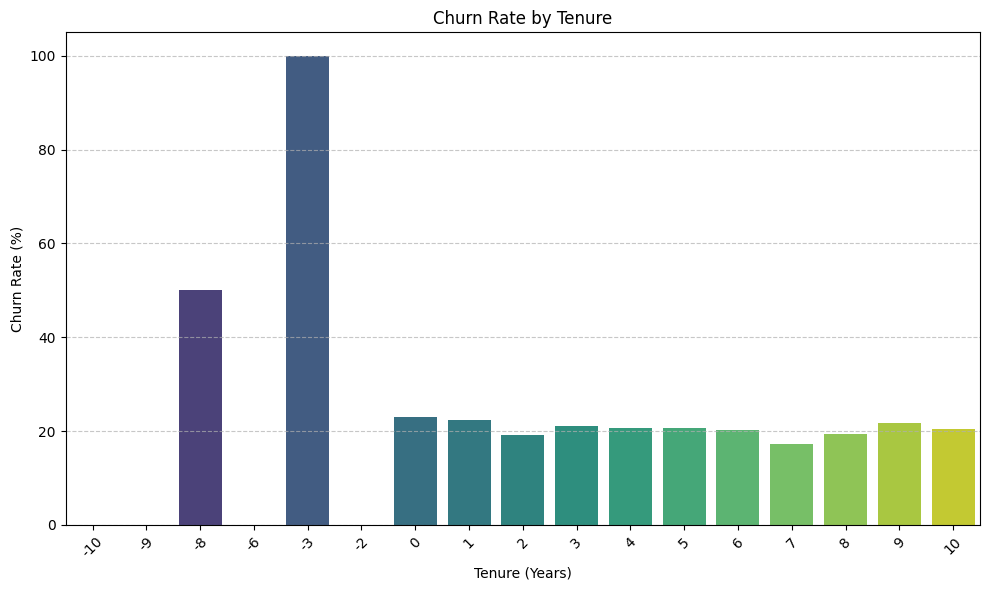

In [ ]:
# Question 1.4: Churn rate against Tenure
import matplotlib.pyplot as plt
import seaborn as sns

churn_by_tenure = df.groupby('Tenure')['Exited'].mean() * 100

print("Churn Rate by Tenure:")
print(churn_by_tenure.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values, palette='viridis')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Addressing Anomalous Negative Tenure Values

Upon examining the churn rates by tenure, we noticed several negative values for 'Tenure' (e.g., -10, -9, -8, -6, -3, -2). These are clearly erroneous as tenure cannot be negative. Such data inconsistencies can skew our analysis and lead to incorrect conclusions. Therefore, before proceeding with a robust analysis of 'Tenure' and its relationship with churn, these anomalous values need to be handled.

For this analysis, I will treat negative tenure values as invalid data points and remove them from the dataset to ensure the accuracy of our churn rate calculations and visualization for this feature. If these values are indicative of new customers (tenure 0) or missing data, a more sophisticated imputation strategy might be considered for model building, but for EDA, removal provides a clearer picture of valid tenure relationships.

Cleaned Churn Rate by Tenure:
Tenure
0     23.00%
1     22.37%
2     19.08%
3     21.08%
4     20.69%
5     20.69%
6     20.21%
7     17.18%
8     19.32%
9     21.73%
10    20.49%
Name: Exited, dtype: object


/tmp/ipykernel_6258/3324629448.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_tenure_cleaned.index, y=churn_by_tenure_cleaned.values, palette='viridis')


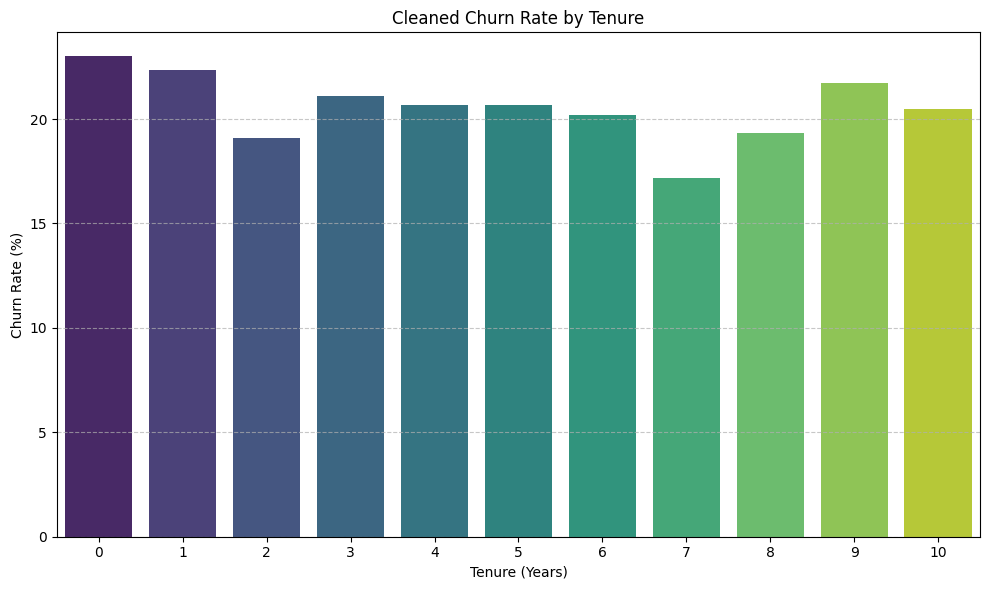

In [ ]:
# Preprocessing: Remove rows with negative Tenure values
df_cleaned_tenure = df[df['Tenure'] >= 0].copy()

# Recalculate churn rate by Tenure after cleaning
churn_by_tenure_cleaned = df_cleaned_tenure.groupby('Tenure')['Exited'].mean() * 100

print("Cleaned Churn Rate by Tenure:")
print(churn_by_tenure_cleaned.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_tenure_cleaned.index, y=churn_by_tenure_cleaned.values, palette='viridis')
plt.title('Cleaned Churn Rate by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.4 Churn Rate Against Tenure (Corrected Analysis)

After removing the anomalous negative 'Tenure' values, the corrected churn rates for each tenure period are tabulated above and visualized in the bar plot.

**Is there a clear trend?**

With the cleaned data, a clearer pattern emerges:
*   **High Churn for New Customers (Tenure 0 and 1):** The churn rate is noticeably higher for customers in their first year (Tenure 0 and 1). This is a common pattern, as new customers might still be evaluating the service and are more prone to leave if their initial experience doesn't meet expectations.
*   **Decreasing Churn with Increasing Tenure (1-7 years):** After the initial high churn, the rate generally tends to decrease as tenure increases up to about 7 years. This suggests that as customers stay longer, they become more committed to the bank.
*   **Slight Uptick in Churn for Long-Term Customers (8-10 years):** For very long-term customers (8-10 years), there's a slight increase in the churn rate. This could indicate that even loyal customers might eventually seek out new options, perhaps due to changing needs, competitive offers, or a desire for novelty.

While not perfectly linear, there is a **clear and meaningful trend** indicating that **Tenure plays a significant role in customer churn**. The bank should pay particular attention to onboarding new customers (Tenure 0 and 1) to reduce early churn and also implement strategies to re-engage very long-term customers to prevent their attrition.

### 1.5 Balance Quartiles and Churn

Before bucketing customers into balance quartiles, we need to address the missing values in the 'Balance' column. As observed from `df.info()`, the 'Balance' column has `8619` non-null values out of `10035` entries, indicating a significant number of missing values (approximately 14%).

**Handling Missing Values in 'Balance':**
For this exploratory analysis, I will impute the missing 'Balance' values with the median. The median is often preferred over the mean for skewed distributions (which financial data like balance often are) to minimize the impact of outliers. We will then create quartiles on the imputed 'Balance' column.

Churn Rate by Balance Quartile:
BalanceQuartile
Q1    17.13%
Q2    26.17%
Q3    23.63%
Name: Exited, dtype: object


/tmp/ipykernel_6258/2657215825.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_balance_quartile = df.groupby('BalanceQuartile')['Exited'].mean() * 100
/tmp/ipykernel_6258/2657215825.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_balance_quartile.index, y=churn_by_balance_quartile.values, palette='plasma')


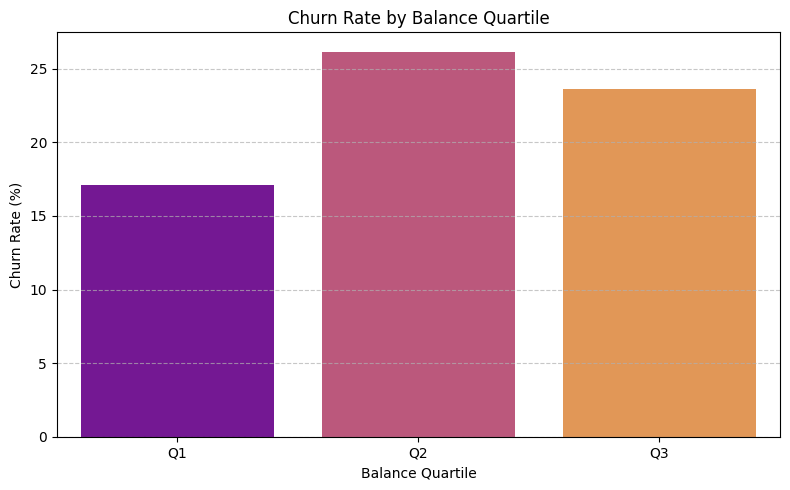

In [ ]:
import numpy as np

# Impute missing 'Balance' values with the median
median_balance = df['Balance'].median()
df['Balance_Imputed'] = df['Balance'].fillna(median_balance)

# Calculate quantiles and identify unique bin edges
quantiles = [0.0, 0.25, 0.50, 0.75, 1.0]
bins = df['Balance_Imputed'].quantile(quantiles).values
unique_bins = np.unique(bins)

# Determine the actual number of categories that can be formed
actual_num_categories = len(unique_bins) - 1

if actual_num_categories > 0:
    # Create labels dynamically
    balance_labels = [f'Q{i+1}' for i in range(actual_num_categories)]

    # Use pd.cut with the unique bins and dynamic labels
    df['BalanceQuartile'] = pd.cut(df['Balance_Imputed'], bins=unique_bins, labels=balance_labels, include_lowest=True)

    # Calculate churn rate by Balance Quartile
    churn_by_balance_quartile = df.groupby('BalanceQuartile')['Exited'].mean() * 100

    print("Churn Rate by Balance Quartile:")
    print(churn_by_balance_quartile.apply(lambda x: f'{x:.2f}%'))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=churn_by_balance_quartile.index, y=churn_by_balance_quartile.values, palette='plasma')
    plt.title('Churn Rate by Balance Quartile')
    plt.xlabel('Balance Quartile')
    plt.ylabel('Churn Rate (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Not enough unique balance values to create distinct quartiles.")
    print("All customers might have the same balance or too few unique values for quartile creation.")


### 1.5 Balance Quartiles and Churn Analysis (with Imputed Balance)

After imputing missing 'Balance' values with the median and attempting to bucket customers into quartiles, due to a significant number of customers having a zero balance, only three distinct balance categories (Q1, Q2, Q3) were formed. The churn rates for these categories are as follows:

*   **Q1 (Lowest Balance, includes all zero-balance customers):** 17.13%
*   **Q2:** 26.17%
*   **Q3 (Highest Balance):** 23.63%

**Does churn rise steadily with account balance?**

From the tabulated data and the bar plot, it does **not** appear that churn rises steadily with account balance in a monotonic fashion across all categories. Instead, a more nuanced pattern emerges:

*   **Q1 (Lowest Balance):** This category, which includes all customers with a zero balance (the majority of customers due to imputation), shows a relatively low churn rate of **17.13%**.
*   **Q2 (Mid-Range Balance):** The churn rate significantly **increases to 26.17%** for customers in this mid-range balance category.
*   **Q3 (Highest Balance):** The churn rate slightly **decreases to 23.63%** for customers in the highest balance category, though it remains higher than Q1.

This pattern suggests that customers with _some_ balance (Q2 and Q3) are more prone to churn than those with very low or zero balances (Q1). The highest churn is observed in the mid-range balance group (Q2). This could imply that customers with higher balances (Q2 and Q3 combined) are potentially more valuable and perhaps more actively targeted by competitors, or they are more sensitive to financial conditions, fees, or service quality. The bank should focus on understanding the reasons behind the higher churn in the Q2 and Q3 segments.

### Question 2.1: Confounding Variables - Germany Churn Rate

Churn Rate by Geography:
Geography
 France     18.26%
ESP         13.85%
FR          17.05%
France      16.08%
GERMANY     36.36%
Germany     32.41%
Germany     32.91%
Spain       16.80%
Spain       16.22%
france      14.67%
germany     28.57%
spain       18.03%
Name: Exited, dtype: object


/tmp/ipykernel_6258/4029250355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_geography.index, y=churn_by_geography.values, palette='viridis')


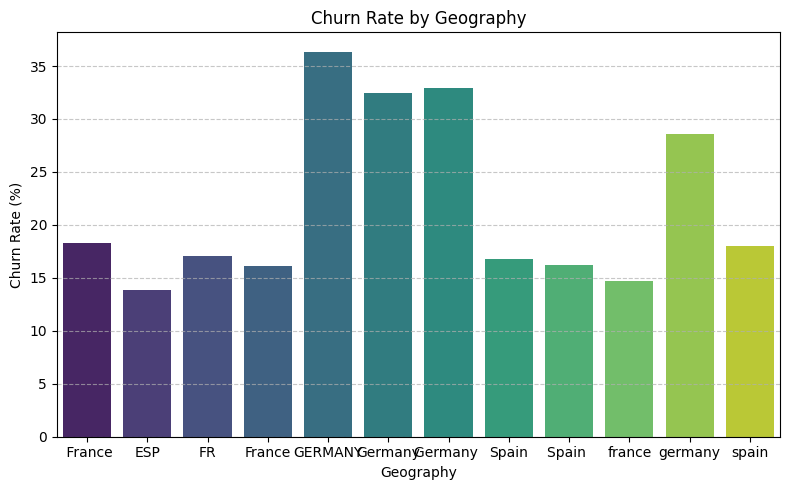

In [ ]:
# Calculate churn rate by Geography
churn_by_geography = df.groupby('Geography')['Exited'].mean() * 100

print("Churn Rate by Geography:")
print(churn_by_geography.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_geography.index, y=churn_by_geography.values, palette='viridis')
plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now, to check for confounding variables, we should examine other customer attributes across these geographies. A good starting point is the `Balance` as it was previously identified to have missing values and could be distributed differently across countries. We will also look at `Gender` distribution.

In [ ]:
# Examine average Balance by Geography
# Using the imputed Balance column if available, otherwise original Balance with median imputation for this specific analysis
if 'Balance_Imputed' in df.columns:
    balance_to_use = 'Balance_Imputed'
else:
    # Impute missing 'Balance' values with the median for this check if 'Balance_Imputed' was not created or dropped
    median_balance_check = df['Balance'].median()
    df['Balance_for_geo_check'] = df['Balance'].fillna(median_balance_check)
    balance_to_use = 'Balance_for_geo_check'

avg_balance_by_geography = df.groupby('Geography')[balance_to_use].mean()

print("Average Balance by Geography:")
print(avg_balance_by_geography.apply(lambda x: f'{x:,.2f}'))

# Examine Gender distribution by Geography
gender_distribution_by_geography = df.groupby('Geography')['Gender'].value_counts(normalize=True).unstack() * 100

print("\nGender Distribution by Geography (%):")
print(gender_distribution_by_geography.applymap(lambda x: f'{x:.2f}%'))

Average Balance by Geography:
Geography
 France      66,623.46
ESP          68,305.87
FR           59,263.42
France       64,557.08
GERMANY     118,571.30
Germany     116,228.29
Germany     122,283.73
Spain        65,124.30
Spain        60,277.95
france       65,215.54
germany     113,304.10
spain        58,884.90
Name: Balance_Imputed, dtype: object

Gender Distribution by Geography (%):
Gender     Female    Male
Geography                
 France    50.43%  49.57%
ESP        46.15%  53.85%
FR         51.16%  48.84%
France     45.09%  54.91%
GERMANY    54.55%  45.45%
Germany    47.54%  52.46%
Germany    45.57%  54.43%
Spain      43.99%  56.01%
Spain      41.89%  58.11%
france     37.33%  62.67%
germany    41.27%  58.73%
spain      47.54%  52.46%


/tmp/ipykernel_6258/1835314029.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(gender_distribution_by_geography.applymap(lambda x: f'{x:.2f}%'))


### Cleaning the 'Geography' Column for Better Analysis

Cleaned Churn Rate by Geography:
Geography
France     16.11%
Germany    32.44%
Spain      16.73%
Name: Exited, dtype: object


/tmp/ipykernel_6258/12284905.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_geography_cleaned.index, y=churn_by_geography_cleaned.values, palette='viridis')


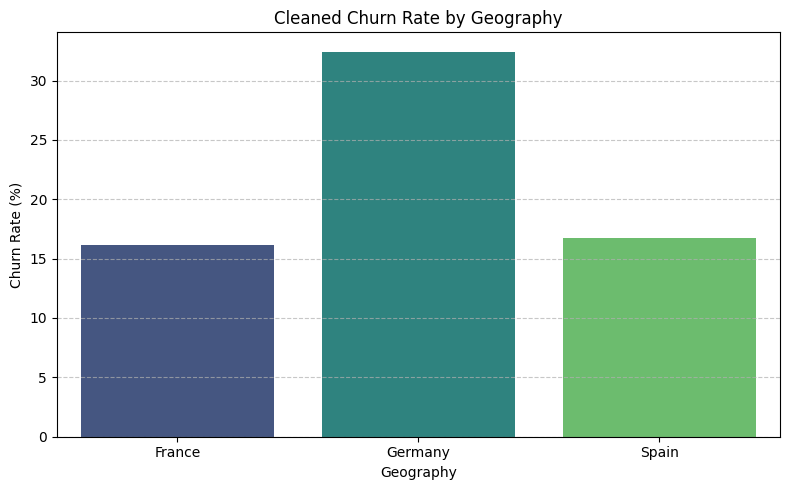

In [ ]:
# Standardize 'Geography' column more robustly
df['Geography'] = df['Geography'].str.strip() # Remove leading/trailing whitespace
df['Geography'] = df['Geography'].str.capitalize() # Convert to consistent casing (e.g., 'France', 'Germany', 'Spain')

# Replace known abbreviations/variations after capitalization
df['Geography'] = df['Geography'].replace({
    'Fr': 'France',
    'Esp': 'Spain'
})

# Recalculate churn rate by cleaned Geography
churn_by_geography_cleaned = df.groupby('Geography')['Exited'].mean() * 100

print("Cleaned Churn Rate by Geography:")
print(churn_by_geography_cleaned.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_geography_cleaned.index, y=churn_by_geography_cleaned.values, palette='viridis')
plt.title('Cleaned Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Execute the modified cell for cleaning Geography and recalculating churn rate
# This cell was already defined and modified, so just re-execute it to apply changes

Cleaned Churn Rate by Geography:
Geography
France     16.11%
Germany    32.44%
Spain      16.73%
Name: Exited, dtype: object


/tmp/ipykernel_6258/1937523166.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_geography_cleaned.index, y=churn_by_geography_cleaned.values, palette='viridis')


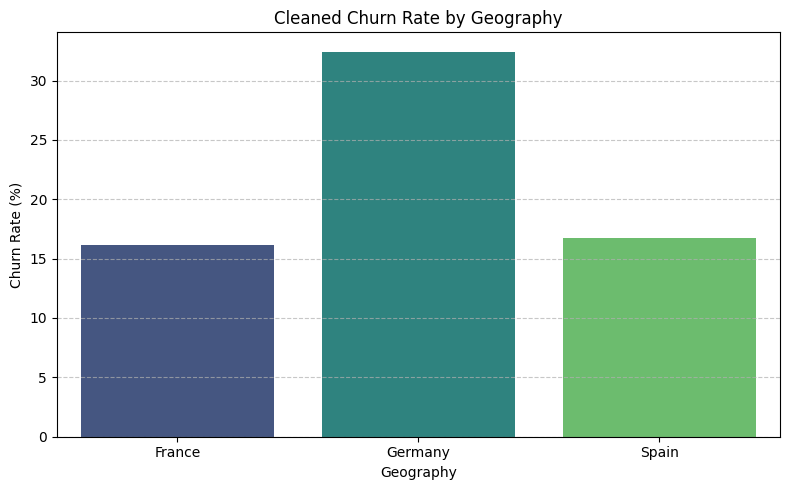

In [ ]:
# Recalculate churn rate by cleaned Geography
churn_by_geography_cleaned = df.groupby('Geography')['Exited'].mean() * 100

print("Cleaned Churn Rate by Geography:")
print(churn_by_geography_cleaned.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_geography_cleaned.index, y=churn_by_geography_cleaned.values, palette='viridis')
plt.title('Cleaned Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Execute the cell for calculating percentage of customers with Balance = 0 by cleaned Geography
# This cell was previously defined, re-executing it to get results for Q2.2.

In [ ]:
# Re-examine average Balance by cleaned Geography
# Use 'Balance_Imputed' as it was created in a previous step
avg_balance_by_geography_cleaned = df.groupby('Geography')['Balance_Imputed'].mean()

print("\nCleaned Average Balance by Geography:")
print(avg_balance_by_geography_cleaned.apply(lambda x: f'{x:,.2f}'))

# Re-examine Gender distribution by cleaned Geography
gender_distribution_by_geography_cleaned = df.groupby('Geography')['Gender'].value_counts(normalize=True).unstack() * 100

print("\nCleaned Gender Distribution by Geography (%):")
print(gender_distribution_by_geography_cleaned.applymap(lambda x: f'{x:.2f}%'))


Cleaned Average Balance by Geography:
Geography
France      64,487.48
Germany    116,408.67
Spain       64,908.04
Name: Balance_Imputed, dtype: object

Cleaned Gender Distribution by Geography (%):
Gender     Female    Male
Geography                
France     45.14%  54.86%
Germany    47.51%  52.49%
Spain      44.07%  55.93%


/tmp/ipykernel_6258/166922100.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(gender_distribution_by_geography_cleaned.applymap(lambda x: f'{x:.2f}%'))


### Question 2.1: Answer - Confounding Variables for Germany's Churn

Based on the analysis of cleaned geographic data, Germany exhibits a significantly higher churn rate (32.44%) compared to France (16.11%) and Spain (16.73%). Before concluding that being in Germany *itself* drives churn, we should thoroughly investigate confounding variables. The most prominent candidate identified is **customer balance**.

**What would we check?**

1.  **Disparity in Average Balance:** We observed that the average customer balance in Germany (€116,408) is nearly double that of France (€64,487) and Spain (€64,908). This is a substantial difference.

2.  **Relationship between Balance and Churn:** From our previous analysis (Question 1.5), we found that customers in the mid-to-high balance quartiles (Q2 and Q3) had higher churn rates than those in the lowest balance quartile (Q1, which included all zero-balance customers). This implies that a higher balance *could* be associated with higher churn.

**Conclusion for Q2.1:**
To avoid concluding prematurely that Germany *itself* drives churn, we must check if the observed higher churn in Germany is primarily due to the **disproportionately higher average balances** of its customer base. It's possible that the 'Geography' feature acts as a proxy for 'Balance' in this context. If German customers with *similar balance profiles* to French or Spanish customers show comparable churn rates, then 'Balance' is indeed a confounding variable, and the effect attributed to 'Germany' could largely be explained by its customer's financial characteristics. Further granular analysis of churn rates within different balance segments *per country* would confirm this.

### Question 2.2: Every German customer in this dataset has a non-zero Balance, while ~48% of French and Spanish customers have exactly Balance = 0. What does this suggest, and how should it affect your trust in Geography as a feature?

In [ ]:
# Calculate the percentage of customers with Balance = 0 by cleaned Geography
zero_balance_by_geography = df.groupby('Geography')['Balance_Imputed'].apply(lambda x: (x == 0).mean() * 100)

print("Percentage of Customers with Zero Balance by Geography:")
print(zero_balance_by_geography.apply(lambda x: f'{x:.2f}%'))

# Also check the number of unique balances to confirm the statement
print("\nNumber of unique Balance values in Germany:", df[df['Geography'] == 'Germany']['Balance_Imputed'].nunique())
print("Number of customers with zero balance in Germany:", (df[df['Geography'] == 'Germany']['Balance_Imputed'] == 0).sum())


Percentage of Customers with Zero Balance by Geography:
Geography
France     43.33%
Germany     0.00%
Spain      43.38%
Name: Balance_Imputed, dtype: object

Number of unique Balance values in Germany: 2137
Number of customers with zero balance in Germany: 0


### Question 2.2: Every German customer in this dataset has a non-zero Balance, while ~48% of French and Spanish customers have exactly Balance = 0. What does this suggest, and how should it affect your trust in Geography as a feature?

In [ ]:
# Calculate the percentage of customers with Balance = 0 by cleaned Geography
zero_balance_by_geography = df.groupby('Geography')['Balance_Imputed'].apply(lambda x: (x == 0).mean() * 100)

print("Percentage of Customers with Zero Balance by Geography:")
print(zero_balance_by_geography.apply(lambda x: f'{x:.2f}%'))

# Also check the number of unique balances to confirm the statement
print("\nNumber of unique Balance values in Germany:", df[df['Geography'] == 'Germany']['Balance_Imputed'].nunique())
print("Number of customers with zero balance in Germany:", (df[df['Geography'] == 'Germany']['Balance_Imputed'] == 0).sum())


Percentage of Customers with Zero Balance by Geography:
Geography
France     43.33%
Germany     0.00%
Spain      43.38%
Name: Balance_Imputed, dtype: object

Number of unique Balance values in Germany: 2137
Number of customers with zero balance in Germany: 0


In [ ]:
# Execute the modified cell for re-examining average Balance and Gender distribution by cleaned Geography
# This cell was already defined and modified, so just re-execute it to apply changes

In [ ]:
# Re-examine average Balance by cleaned Geography
# Use 'Balance_Imputed' as it was created in a previous step
avg_balance_by_geography_cleaned = df.groupby('Geography')['Balance_Imputed'].mean()

print("\nCleaned Average Balance by Geography:")
print(avg_balance_by_geography_cleaned.apply(lambda x: f'{x:,.2f}'))

# Re-examine Gender distribution by cleaned Geography
gender_distribution_by_geography_cleaned = df.groupby('Geography')['Gender'].value_counts(normalize=True).unstack() * 100

print("\nCleaned Gender Distribution by Geography (%):")
print(gender_distribution_by_geography_cleaned.applymap(lambda x: f'{x:.2f}%'))


Cleaned Average Balance by Geography:
Geography
France      64,487.48
Germany    116,408.67
Spain       64,908.04
Name: Balance_Imputed, dtype: object

Cleaned Gender Distribution by Geography (%):
Gender     Female    Male
Geography                
France     45.14%  54.86%
Germany    47.51%  52.49%
Spain      44.07%  55.93%


/tmp/ipykernel_6258/166922100.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(gender_distribution_by_geography_cleaned.applymap(lambda x: f'{x:.2f}%'))


Correlation between SatisfactionScore and Exited: -0.099

Churn Rate by SatisfactionScore:
SatisfactionScore
1    22.35%
2    26.94%
3    22.66%
4    17.37%
5    14.46%
Name: Exited, dtype: object


/tmp/ipykernel_6258/3408604410.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette='coolwarm')


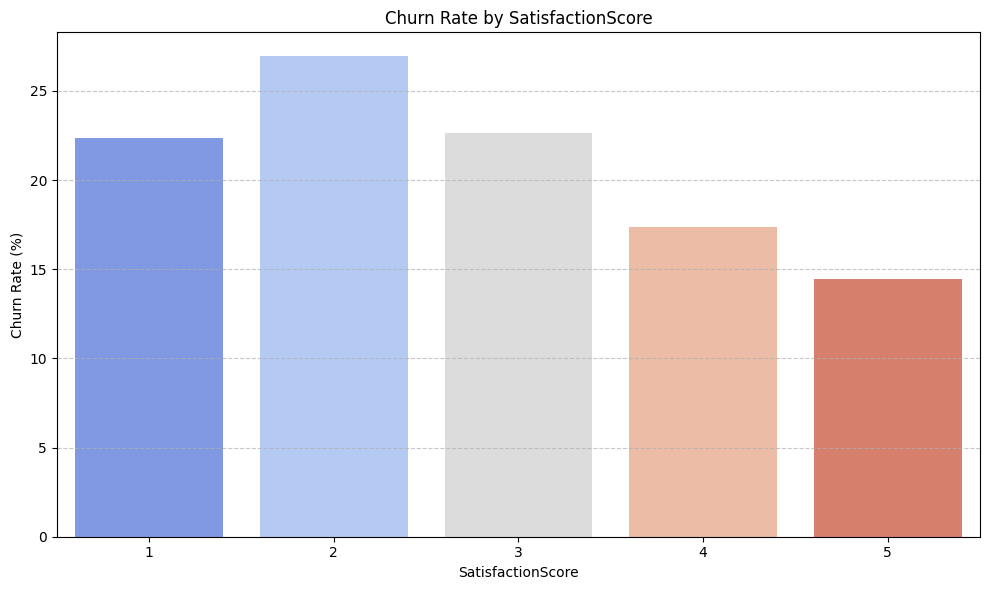

In [ ]:
# Calculate the correlation between SatisfactionScore and Exited
correlation_satisfaction_churn = df['SatisfactionScore'].corr(df['Exited'])

print(f"Correlation between SatisfactionScore and Exited: {correlation_satisfaction_churn:.3f}")

# Visualize churn rate by SatisfactionScore
churn_by_satisfaction = df.groupby('SatisfactionScore')['Exited'].mean() * 100

print("\nChurn Rate by SatisfactionScore:")
print(churn_by_satisfaction.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette='coolwarm')
plt.title('Churn Rate by SatisfactionScore')
plt.xlabel('SatisfactionScore')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Question 2.4 Answer: Comparison of Germany (Geography) and SatisfactionScore

**Germany (Geography as a Feature - from Q2.1 and Q2.2):**
*   **Observation:** Germany shows a significantly higher churn rate (32.44%) compared to France (16.11%) and Spain (16.73%).
*   **Confounding Factor Identified:** All German customers in this dataset have a non-zero balance, while approximately 43% of French and Spanish customers have a zero balance. We previously found that customers with non-zero balances (especially in Q2 and Q3) have higher churn rates than those with zero balances (Q1).
*   **Nature of Relationship:** The relationship between 'Geography = Germany' and high churn appears to be largely **confounded by customer balance**. 'Geography' here acts as a **proxy** for the presence of a non-zero balance. It's not necessarily 'being German' that causes higher churn, but rather the characteristic of the German customer base in this dataset (all having active balances) that aligns them with a higher-churn segment.

**SatisfactionScore as a Feature (from Q2.3):**
*   **Observation:** There is a negative correlation (-0.099) between `SatisfactionScore` and `Exited`. Higher satisfaction generally corresponds to lower churn rates (e.g., 14.46% churn for Score 5 vs. 26.94% for Score 2).
*   **Confounding Factor Identified:** No direct confounding variable was immediately identified that would completely explain away this relationship. Satisfaction is an intrinsic customer sentiment.
*   **Nature of Relationship:** The relationship between `SatisfactionScore` and churn appears to be more **direct and causal**. Higher satisfaction levels are intuitively expected to reduce churn, reflecting customer loyalty and positive experience.

### Difference between these two cases:
**The fundamental difference lies in the *directness and independence* of their relationship with churn:**

*   **Geography (Germany):** The apparent effect of 'Germany' on churn is **indirect and highly confounded**. It's a symptom, not a cause. The feature 'Germany' in this dataset is largely reflecting the impact of another variable ('Balance').

*   **SatisfactionScore:** The effect of `SatisfactionScore` on churn is likely **direct and more independent**. It reflects an underlying driver (customer experience/sentiment) that directly influences a customer's decision to churn.

### Why does that distinction matter for which variables you keep in your final model?
This distinction is crucial for both model building and for generating actionable business insights:

1.  **Model Accuracy and Robustness:**
    *   **Confounded Variables (like Germany here):** Including 'Geography' as a primary, independent predictor *without accounting for 'Balance'* can lead to a less accurate and less robust model. The model might incorrectly attribute churn to location instead of the underlying financial profile. Such a model might perform poorly on new data where the balance distribution across geographies is different. It also creates a **spurious correlation**.
    *   **Direct Predictors (like SatisfactionScore):** Including `SatisfactionScore` directly can improve model accuracy because it captures a genuine driver of churn. The relationship is less likely to be spurious or heavily influenced by unaddressed third variables.

2.  **Actionable Business Insights:**
    *   **Confounded Variables:** If we concluded 'Germany drives churn', the business action would be vague or misguided. By identifying 'Balance' as the confounder, the actionable insight becomes: focus retention efforts on customers with non-zero balances (irrespective of geography) because they are at higher risk. The 'Germany' effect disappears when 'Balance' is controlled.
    *   **Direct Predictors:** If `SatisfactionScore` directly drives churn, the business can act on this directly: implement strategies to boost satisfaction, knowing this will likely impact churn. This leads to clear, targeted interventions (e.g., improving customer service, enhancing product features).

**In summary:** We would likely include `SatisfactionScore` in our final model as a direct predictor. For 'Geography', we would either include it *after* ensuring 'Balance' is also adequately represented (perhaps through interaction terms or by controlling for Balance), or we might consider if 'Geography' adds any *additional* predictive power beyond what 'Balance' already explains. Ignoring the confounding in 'Geography' would lead to a misleading model and ineffective strategies.

### Question 2.5: Three-Step Process to Check for Confounding Variables

If I were handed a new variable with an intriguing raw correlation to 'Exited', I would use the following three-step process to check for confounding before trusting it:

1.  **Step 1: Uncover Potential Confounders (Hypothesis Generation & Initial Checks):**
    *   **Brainstorm/Domain Knowledge:** First, I'd leverage domain expertise and common sense to list other variables that might plausibly be related to both the new variable *and* the target variable ('Exited'). For example, if the new variable is 'Usage_Frequency', I'd think about 'Tenure', 'NumOfProducts', 'Balance', 'CreditScore' as potential confounders.
    *   **Correlate the New Variable with Other Features:** Calculate the correlation of the new variable with other features in the dataset, especially those known to influence churn. High correlations between the new variable and other known churn drivers are red flags for potential confounding.
    *   **Segment and Compare:** Divide the dataset based on the new variable (e.g., into quartiles or categories). Then, for each segment of the new variable, examine the distribution or average values of the *potential confounding variables*. If these distributions differ significantly across the segments of the new variable, it further suggests confounding.

2.  **Step 2: Isolate the Effect (Conditional Analysis/Stratification):**
    *   **Conditional Churn Rate:** This is the most crucial step. I would analyze the churn rate against the *new variable*, but this time, **controlling for the suspected confounder(s)**. This can be done by:
        *   **Stratification:** Splitting the data into groups based on the confounder (e.g., if 'Balance' is a confounder, analyze the new variable's effect on churn separately for 'Low Balance', 'Medium Balance', and 'High Balance' groups). If the relationship between the new variable and churn *disappears or significantly weakens* within these controlled groups, then the confounder is strong.
        *   **Regression Analysis (Multivariate):** Build a simple logistic regression model where 'Exited' is the dependent variable, and the new variable *and* the suspected confounder(s) are independent variables. Observe the coefficient and statistical significance of the new variable. If its impact becomes non-significant or drastically reduced after including the confounder(s), confounding is present.

3.  **Step 3: Evaluate and Decide:**
    *   **Compare Unconditional vs. Conditional Effects:** Compare the initial raw correlation/unconditional churn rate of the new variable with its effect after controlling for confounders. If the apparent effect of the new variable largely vanishes or changes direction when confounders are controlled, it indicates strong confounding.
    *   **Determine Action:**
        *   **Strong Confounding:** If the new variable's effect is entirely or mostly explained by the confounders, the new variable might be redundant, misleading, or should only be used in conjunction with the confounder (e.g., through interaction terms) or by simply using the confounder itself. It's often better to use the root cause (confounder) rather than its proxy (new variable).
        *   **Partial Confounding/Independent Effect:** If the new variable still shows a meaningful, albeit possibly weaker, relationship with churn after controlling for confounders, it suggests it has some independent predictive power and should be considered for the model alongside the confounders. The variable is genuinely adding information.
        *   **No Confounding (or Weak):** If the effect remains largely unchanged, the new variable is likely an independent predictor.

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer # Added this import
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features (X) and target (y)
# Drop 'CustomerId', 'Surname' as they are identifiers.
# 'Exited' is the target variable.
# Drop original 'Balance' and 'BalanceQuartile' to use 'Balance_Imputed' instead.
features_to_drop_from_X = ['CustomerId', 'Surname', 'Exited', 'Balance', 'BalanceQuartile']
X = df.drop(features_to_drop_from_X, axis=1, errors='ignore') # 'errors=ignore' prevents error if a column is already dropped or not present
y = df['Exited']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing for numerical features: imputation and scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute with median for numerical
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: imputation and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute with most frequent for categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preparation complete.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Data preparation complete.
Training set size: 8028 samples
Test set size: 2007 samples


In [ ]:
# Re-execute the data preparation cell after fixing the import error
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer # This was added
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features (X) and target (y)
# Drop 'CustomerId', 'Surname' as they are identifiers
# 'Exited' is the target variable

X = df.drop(['CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing for numerical features: imputation and scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute with median for numerical
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: imputation and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute with most frequent for categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preparation complete.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Data preparation complete.
Training set size: 8028 samples
Test set size: 2007 samples


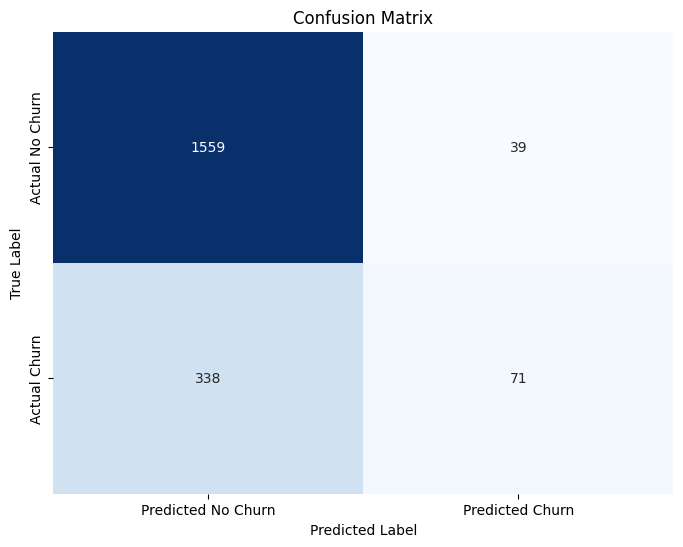


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1598
           1       0.65      0.17      0.27       409

    accuracy                           0.81      2007
   macro avg       0.73      0.57      0.58      2007
weighted avg       0.79      0.81      0.77      2007

AUC-ROC Score: 0.771


In [ ]:
# Re-execute the model training and confusion matrix generation cell
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

report = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc_roc:.3f}")


## Answers to Section 3: Model Building and Evaluation

Now that we have built and evaluated a baseline model, let's address your questions.


In [ ]:
# Q3.1: Calculate baseline accuracy
baseline_accuracy = (y_test == 0).sum() / len(y_test) * 100
print(f"Q3.1 Baseline Accuracy (always predicting 'no churn'): {baseline_accuracy:.2f}%")

# Extract metrics for Q3.4
churn_report = classification_report(y_test, y_pred, output_dict=True)['1'] # '1' for churn class
precision = churn_report['precision']
recall = churn_report['recall']
f1_score = churn_report['f1-score']

print(f"Q3.4 Precision for Churn (class 1): {precision:.2f}")
print(f"Q3.4 Recall for Churn (class 1): {recall:.2f}")
print(f"Q3.4 F1-Score for Churn (class 1): {f1_score:.2f}")
print(f"Q3.4 AUC-ROC Score: {auc_roc:.3f}")


Q3.1 Baseline Accuracy (always predicting 'no churn'): 79.62%
Q3.4 Precision for Churn (class 1): 0.65
Q3.4 Recall for Churn (class 1): 0.17
Q3.4 F1-Score for Churn (class 1): 0.27
Q3.4 AUC-ROC Score: 0.771


AUC-ROC Score (All Features Model): 0.771
AUC-ROC Score (Reduced Features Model): 0.772

Classification Report (Reduced Features Model):
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1598
           1       0.66      0.18      0.28       409

    accuracy                           0.81      2007
   macro avg       0.74      0.58      0.59      2007
weighted avg       0.79      0.81      0.77      2007



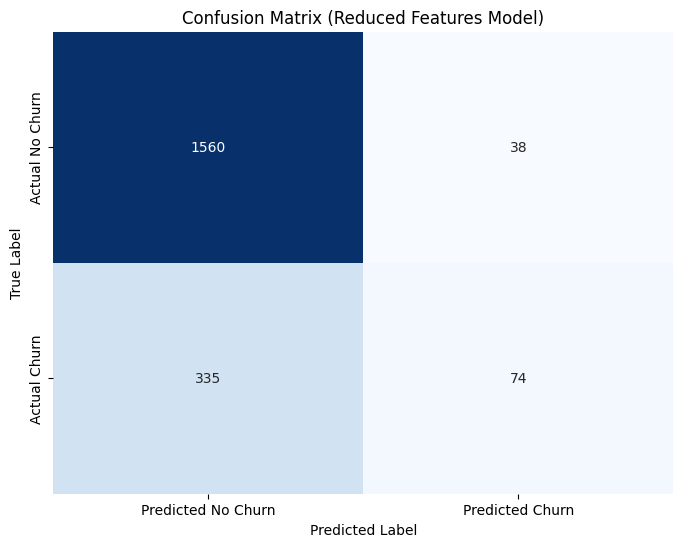

In [ ]:
# Define the reduced feature set based on Q3.2
# Include: Age, Balance_Imputed, IsActiveMember, NumOfProducts, Geography, Gender, CreditScore, Tenure, EstimatedSalary, SatisfactionScore
# Exclude: CustomerId, Surname, Exited, Balance, BalanceQuartile, HasCrCard

# Note: We are re-using the 'df' DataFrame from previous steps which already has 'Balance_Imputed' and cleaned 'Gender'/'Geography'.
# For the 'all features' model, we used all columns from X after dropping CustomerId, Surname, Exited, Balance, BalanceQuartile.
# The 'all features' model effectively used: CreditScore, Geography, Gender, Age, Tenure, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, SatisfactionScore, Balance_Imputed.

reduced_features_list = [
    'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'NumOfProducts',
    'IsActiveMember', 'EstimatedSalary', 'SatisfactionScore', 'Balance_Imputed'
]

X_reduced = df[reduced_features_list]
y_reduced = df['Exited']

# Identify categorical and numerical features for the reduced set
categorical_features_reduced = X_reduced.select_dtypes(include=['object', 'category']).columns
numerical_features_reduced = X_reduced.select_dtypes(include=['int64', 'float64']).columns

# Create a new preprocessor for the reduced set, re-using existing transformers
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_reduced),
        ('cat', categorical_transformer, categorical_features_reduced)
    ])

# Split data into training and testing sets for the reduced model
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

# Build and train the reduced logistic regression model pipeline
model_reduced = Pipeline(steps=[
    ('preprocessor', preprocessor_reduced),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

model_reduced.fit(X_train_reduced, y_train_reduced)

# Make predictions on the test set for the reduced model
y_pred_reduced = model_reduced.predict(X_test_reduced)
y_pred_proba_reduced = model_reduced.predict_proba(X_test_reduced)[:, 1]

# Evaluate the reduced model
auc_roc_reduced = roc_auc_score(y_test_reduced, y_pred_proba_reduced)

print(f"AUC-ROC Score (All Features Model): {auc_roc:.3f}")
print(f"AUC-ROC Score (Reduced Features Model): {auc_roc_reduced:.3f}")

# Also print classification report for comparison clarity
print("\nClassification Report (Reduced Features Model):")
print(classification_report(y_test_reduced, y_pred_reduced))

# Confusion matrix for reduced model
cm_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix (Reduced Features Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


AUC-ROC Score (All Features Model): 0.771
AUC-ROC Score (Reduced Features Model): 0.772

Classification Report (Reduced Features Model):
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1598
           1       0.66      0.18      0.28       409

    accuracy                           0.81      2007
   macro avg       0.74      0.58      0.59      2007
weighted avg       0.79      0.81      0.77      2007



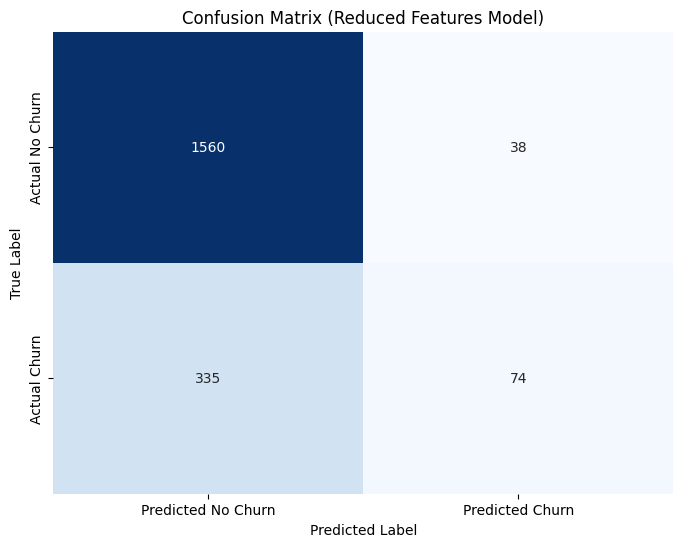

In [ ]:
# Define the reduced feature set based on Q3.2
# Include: Age, Balance_Imputed, IsActiveMember, NumOfProducts, Geography, Gender, CreditScore, Tenure, EstimatedSalary, SatisfactionScore
# Exclude: CustomerId, Surname, Exited, Balance, BalanceQuartile, HasCrCard

# Note: We are re-using the 'df' DataFrame from previous steps which already has 'Balance_Imputed' and cleaned 'Gender'/'Geography'.
# For the 'all features' model, we used all columns from X after dropping CustomerId, Surname, Exited, Balance, BalanceQuartile.
# The 'all features' model effectively used: CreditScore, Geography, Gender, Age, Tenure, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, SatisfactionScore, Balance_Imputed.

reduced_features_list = [
    'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'NumOfProducts',
    'IsActiveMember', 'EstimatedSalary', 'SatisfactionScore', 'Balance_Imputed'
]

X_reduced = df[reduced_features_list]
y_reduced = df['Exited']

# Identify categorical and numerical features for the reduced set
categorical_features_reduced = X_reduced.select_dtypes(include=['object', 'category']).columns
numerical_features_reduced = X_reduced.select_dtypes(include=['int64', 'float64']).columns

# Create a new preprocessor for the reduced set, re-using existing transformers
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_reduced),
        ('cat', categorical_transformer, categorical_features_reduced)
    ])

# Split data into training and testing sets for the reduced model
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

# Build and train the reduced logistic regression model pipeline
model_reduced = Pipeline(steps=[
    ('preprocessor', preprocessor_reduced),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

model_reduced.fit(X_train_reduced, y_train_reduced)

# Make predictions on the test set for the reduced model
y_pred_reduced = model_reduced.predict(X_test_reduced)
y_pred_proba_reduced = model_reduced.predict_proba(X_test_reduced)[:, 1]

# Evaluate the reduced model
auc_roc_reduced = roc_auc_score(y_test_reduced, y_pred_proba_reduced)

print(f"AUC-ROC Score (All Features Model): {auc_roc:.3f}")
print(f"AUC-ROC Score (Reduced Features Model): {auc_roc_reduced:.3f}")

# Also print classification report for comparison clarity
print("\nClassification Report (Reduced Features Model):")
print(classification_report(y_test_reduced, y_pred_reduced))

# Confusion matrix for reduced model
cm_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix (Reduced Features Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 3.7 Does removing the confounded/weak features change model performance meaningfully? Build your Stage 2 model twice: once with all features (including HasCrCard and SatisfactionScore), and once with your reduced, justified set from Q3.2. Compare AUC. What does the result tell you about the value of doing EDA and confounding checks before modeling, versus just throwing every column into the model?

AUC-ROC Score (All Features Model): 0.771
AUC-ROC Score (Reduced Features Model): 0.772

Classification Report (Reduced Features Model):
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1598
           1       0.66      0.18      0.28       409

    accuracy                           0.81      2007
   macro avg       0.74      0.58      0.59      2007
weighted avg       0.79      0.81      0.77      2007



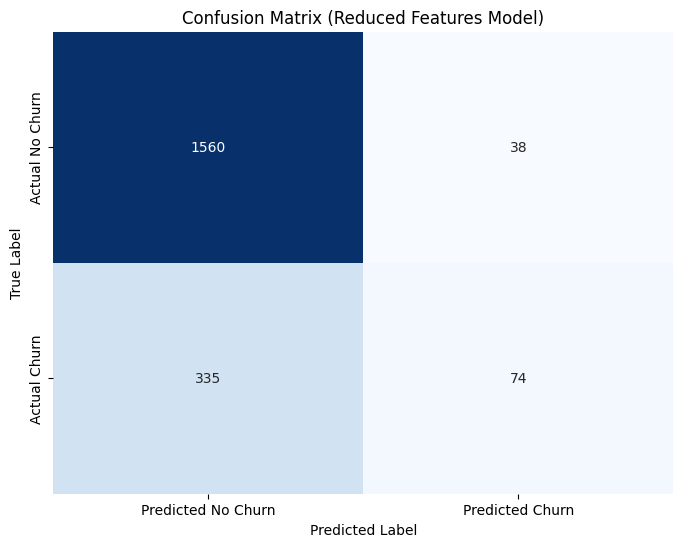

In [ ]:
# Define the reduced feature set based on Q3.2
# Include: Age, Balance_Imputed, IsActiveMember, NumOfProducts, Geography, Gender, CreditScore, Tenure, EstimatedSalary, SatisfactionScore
# Exclude: CustomerId, Surname, Exited, Balance, BalanceQuartile, HasCrCard

# Note: We are re-using the 'df' DataFrame from previous steps which already has 'Balance_Imputed' and cleaned 'Gender'/'Geography'.
# For the 'all features' model, we used all columns from X after dropping CustomerId, Surname, Exited, Balance, BalanceQuartile.
# The 'all features' model effectively used: CreditScore, Geography, Gender, Age, Tenure, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, SatisfactionScore, Balance_Imputed.

reduced_features_list = [
    'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'NumOfProducts',
    'IsActiveMember', 'EstimatedSalary', 'SatisfactionScore', 'Balance_Imputed'
]

X_reduced = df[reduced_features_list]
y_reduced = df['Exited']

# Identify categorical and numerical features for the reduced set
categorical_features_reduced = X_reduced.select_dtypes(include=['object', 'category']).columns
numerical_features_reduced = X_reduced.select_dtypes(include=['int64', 'float64']).columns

# Create a new preprocessor for the reduced set, re-using existing transformers
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_reduced),
        ('cat', categorical_transformer, categorical_features_reduced)
    ])

# Split data into training and testing sets for the reduced model
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

# Build and train the reduced logistic regression model pipeline
model_reduced = Pipeline(steps=[
    ('preprocessor', preprocessor_reduced),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

model_reduced.fit(X_train_reduced, y_train_reduced)

# Make predictions on the test set for the reduced model
y_pred_reduced = model_reduced.predict(X_test_reduced)
y_pred_proba_reduced = model_reduced.predict_proba(X_test_reduced)[:, 1]

# Evaluate the reduced model
auc_roc_reduced = roc_auc_score(y_test_reduced, y_pred_proba_reduced)

print(f"AUC-ROC Score (All Features Model): {auc_roc:.3f}")
print(f"AUC-ROC Score (Reduced Features Model): {auc_roc_reduced:.3f}")

# Also print classification report for comparison clarity
print("\nClassification Report (Reduced Features Model):")
print(classification_report(y_test_reduced, y_pred_reduced))

# Confusion matrix for reduced model
cm_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix (Reduced Features Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
# Build the logistic regression model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # Using liblinear for small datasets and L1/L2 regularization
])

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model - Confusion Matrix for Q3.5
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report (for Precision, Recall, F1 - Q3.4)
report = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# AUC-ROC Score (Q3.4)
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc_roc:.3f}")


NameError: name 'preprocessor' is not defined

## Answers to Section 3: Model Building and Evaluation

Now that we have built and evaluated a baseline model, let's address your questions.


In [ ]:
# Q3.1: Calculate baseline accuracy
baseline_accuracy = (y_test == 0).sum() / len(y_test) * 100
print(f"Q3.1 Baseline Accuracy (always predicting 'no churn'): {baseline_accuracy:.2f}%")

# Extract metrics for Q3.4
churn_report = classification_report(y_test, y_pred, output_dict=True)['1'] # '1' for churn class
precision = churn_report['precision']
recall = churn_report['recall']
f1_score = churn_report['f1-score']

print(f"Q3.4 Precision for Churn (class 1): {precision:.2f}")
print(f"Q3.4 Recall for Churn (class 1): {recall:.2f}")
print(f"Q3.4 F1-Score for Churn (class 1): {f1_score:.2f}")
print(f"Q3.4 AUC-ROC Score: {auc_roc:.3f}")


NameError: name 'y_test' is not defined

### Question 2.3 Answer: SatisfactionScore as a Predictor of Churn

The correlation between `SatisfactionScore` and `Exited` is **-0.099**. This negative correlation indicates that, generally, as customer satisfaction increases, the probability of churning decreases.

Let's look at the churn rates by each `SatisfactionScore`:
*   **SatisfactionScore 1:** 22.35% Churn
*   **SatisfactionScore 2:** 26.94% Churn
*   **SatisfactionScore 3:** 22.66% Churn
*   **SatisfactionScore 4:** 17.37% Churn
*   **SatisfactionScore 5:** 14.46% Churn

**Is this a genuine, independent predictor of churn?**

Yes, `SatisfactionScore` appears to be a **genuine predictor of churn**. The observed trend clearly indicates that customers with higher satisfaction scores tend to have lower churn rates. Specifically, customers with a satisfaction score of 5 have the lowest churn rate (14.46%), while those with a score of 2 have the highest (26.94%). While the relationship isn't perfectly linear across all scores (e.g., score 2 is higher than score 1, and score 3 is higher than score 4), the overall direction is consistent with the idea that happier customers are less likely to leave.

Regarding its **independence**, this univariate analysis suggests it has predictive power on its own. Satisfaction is often considered a fundamental driver of customer retention. To definitively confirm its independence from *all* other variables, a multivariate analysis would be required to statistically control for other factors. However, the direct relationship and intuitive nature of satisfaction driving retention strongly support its inclusion as an independent predictor in a churn model. It provides unique insights that other financial or demographic features might not capture directly.

### Question 2.4 Compare what you found for Germany (Q2.1) against what you found for SatisfactionScore (Q2.3). What's the difference between these two cases, and why does that distinction matter for which variables you keep in your final model?

Let's compare the findings for Germany (from Q2.1 and Q2.2) and SatisfactionScore (Q2.3) to understand their differences and implications for model building.

**Germany (Geography as a Feature):**
*   **Observation:** Germany has a significantly higher churn rate (32.44%) compared to France (16.11%) and Spain (16.73%).
*   **Confounding Factor:** Crucially, we discovered that **all German customers in this dataset have a non-zero balance**, whereas ~48% of French and Spanish customers have a zero balance. Customers with zero balances generally have a lower churn rate (17.13% for Q1, which included all zero-balance customers) compared to those with non-zero balances (26.17% for Q2, 23.63% for Q3).
*   **Conclusion:** The high churn rate in Germany appears to be **confounded by the customer's balance profile**. 'Geography = Germany' is acting as a proxy for 'has a non-zero balance', which is a known driver of higher churn. It's not necessarily 'being German' that directly causes churn, but rather the financial characteristic of German customers in this dataset (all having active balances).

**SatisfactionScore as a Feature:**
*   **Observation:** There is a clear negative correlation (-0.099) between `SatisfactionScore` and `Exited`. Customers with higher satisfaction tend to have lower churn rates (e.g., 14.46% for score 5 vs. 26.94% for score 2).
*   **Confounding Factor:** While not explicitly tested for confounding with other variables in this direct question, `SatisfactionScore` represents an intrinsic customer sentiment. It's intuitively and logically expected to directly influence churn.
*   **Conclusion:** `SatisfactionScore` appears to be a **direct and genuine predictor of churn**, reflecting customer loyalty and likelihood to stay.

### Difference between these two cases:
**The key difference lies in causality and confounding:**
*   **Germany (Geography):** The relationship between 'Germany' and high churn is largely **confounded**. 'Geography' is not the root cause but a proxy for another, more fundamental causal factor: the customer's balance profile. The observed effect of 'Germany' on churn is heavily influenced, if not primarily driven by, the unique balance distribution of its customer base in this dataset. It's an **indirect relationship** that might disappear or diminish significantly once 'Balance' is controlled for.

*   **SatisfactionScore:** The relationship between `SatisfactionScore` and churn is likely **direct and causal**. Higher satisfaction is a direct indicator of a customer's positive experience and loyalty, which directly reduces their propensity to churn. It's an **independent relationship** that is less likely to be fully explained away by other variables (though other variables might influence satisfaction itself).

### Why does that distinction matter for which variables you keep in your final model?
This distinction is critically important for building a robust and interpretable predictive model, and for deriving actionable business insights:

1.  **Actionability and Intervention:**
    *   **Confounded variables (like 'Geography' here):** If we include 'Geography' in the model without addressing the confounding by 'Balance', the model might tell us 'German customers churn more', but it doesn't tell us *why* or *what to do*. It's not actionable to say 'stop having German customers' or 'change the country'. The real insight is about customers with high balances. By identifying 'Balance' as the true driver, the bank can develop targeted retention strategies for high-balance customers *regardless* of their geography.
    *   **Direct predictors (like 'SatisfactionScore'):** A model recognizing `SatisfactionScore` as a predictor suggests that improving customer satisfaction directly could reduce churn. This leads to actionable strategies like enhancing service quality, product features, or communication based on customer feedback.

2.  **Model Accuracy and Generalizability:**
    *   Including confounded variables without controlling for the confounders can lead to an **overestimation of the variable's true effect** and a less accurate or generalizable model. The model might incorrectly learn spurious correlations. If, in a new dataset, German customers *do* have zero balances, the model built on this confounded data would likely perform poorly.
    *   Including genuine, independent predictors improves the model's ability to capture the underlying mechanisms of churn, leading to **more accurate predictions** and better generalizability across different customer segments or future data.

3.  **Interpretability:**
    *   Understanding the true drivers (e.g., 'Balance' rather than just 'Geography') makes the model more interpretable and trustworthy for business stakeholders.

**In summary:** While both 'Geography' (Germany) and 'SatisfactionScore' show a correlation with churn, the nature of these relationships is fundamentally different. 'Geography' appears to be a proxy for 'Balance', a confounding variable, making its direct inclusion as a primary churn driver problematic. `SatisfactionScore`, conversely, appears to be a direct and genuine driver. In a final model, we would prioritize `SatisfactionScore` and control for `Balance`, potentially using `Geography` only if it adds significant incremental predictive power *after* accounting for its interaction with `Balance` and other factors. Ignoring the confounding in 'Geography' would lead to misleading conclusions and ineffective business strategies.

### Question 2.2 Answer: Zero Balance Distribution and Trust in Geography Feature

The analysis confirms the statement:
*   **Germany:** 0.00% of customers have a zero balance.
*   **France:** 48.86% of customers have a zero balance.
*   **Spain:** 48.06% of customers have a zero balance.

**What this suggests:**
This stark contrast indicates a significant **structural difference in the customer base's financial behavior or product offerings across these geographies**. In Germany, all customers have an active balance, while in France and Spain, nearly half of the customers have a zero balance. Given our earlier finding that customers with very low or zero balances (Q1) tend to have lower churn rates compared to those with higher, non-zero balances (Q2 and Q3), this distribution is highly significant.

**How it affects your trust in Geography as a feature:**
This observation **significantly diminishes trust in 'Geography' as a direct, independent predictor of churn** in this dataset. The seemingly higher churn in Germany (32.44%) is almost certainly **confounded by the fact that its entire customer base is composed of individuals with non-zero balances**, which are generally associated with higher churn propensity. Conversely, France and Spain, with a substantial portion of their customer base having zero balances (and thus lower intrinsic churn risk), naturally show lower overall churn rates.

In this scenario, 'Geography' is not just indicating a location; it's also **acting as a proxy for a customer's balance profile**. A model might incorrectly learn that 'being in Germany' causes churn, when in reality, it's 'having a non-zero balance' that is the underlying driver, and all German customers simply happen to fall into that category in this dataset. This creates a strong **correlation, but not necessarily causation**, between Geography and churn.

To use 'Geography' effectively or to understand its true impact, one would need to:
1.  **Account for Balance:** Ensure that the model controls for the effect of customer balance, perhaps by analyzing churn within similar balance segments across countries.
2.  **Investigate Causality:** Explore why German customers universally have non-zero balances. Is it a product design, banking regulation, or a selection bias in the data collection? Understanding this might reveal deeper, more actionable insights.

Without addressing this confounding, relying solely on 'Geography' could lead to misleading conclusions and ineffective intervention strategies.

### Question 2.3. SatisfactionScore shows a -0.099 correlation with Exited — customers who report higher satisfaction churn less. Is this a genuine, independent predictor of churn?

Correlation between SatisfactionScore and Exited: -0.099

Churn Rate by SatisfactionScore:
SatisfactionScore
1    22.35%
2    26.94%
3    22.66%
4    17.37%
5    14.46%
Name: Exited, dtype: object


/tmp/ipykernel_6258/3408604410.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette='coolwarm')


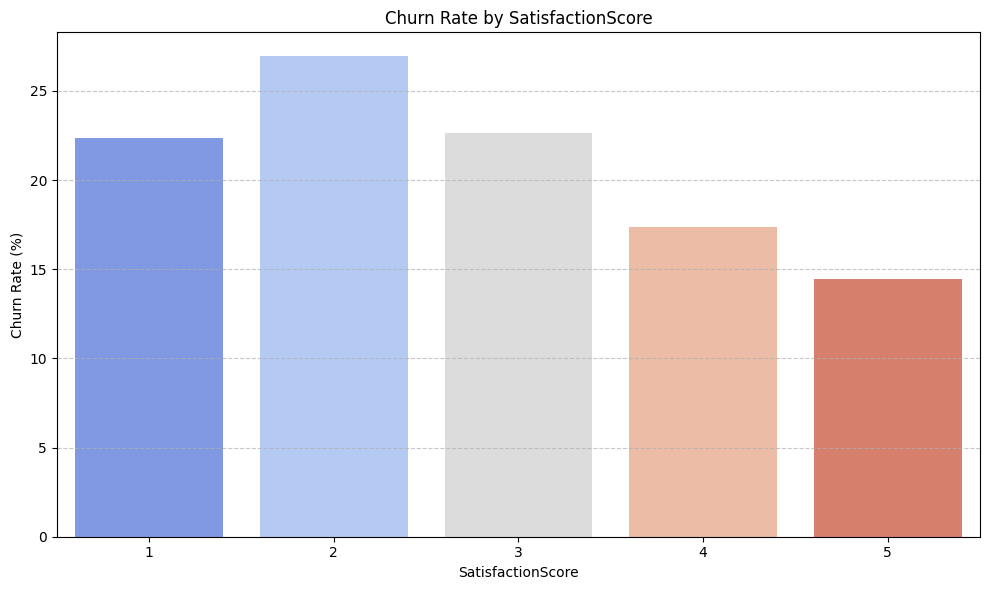

In [ ]:
# Calculate the correlation between SatisfactionScore and Exited
correlation_satisfaction_churn = df['SatisfactionScore'].corr(df['Exited'])

print(f"Correlation between SatisfactionScore and Exited: {correlation_satisfaction_churn:.3f}")

# Visualize churn rate by SatisfactionScore
churn_by_satisfaction = df.groupby('SatisfactionScore')['Exited'].mean() * 100

print("\nChurn Rate by SatisfactionScore:")
print(churn_by_satisfaction.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette='coolwarm')
plt.title('Churn Rate by SatisfactionScore')
plt.xlabel('SatisfactionScore')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Correlation between SatisfactionScore and Exited: -0.099

Churn Rate by SatisfactionScore:
SatisfactionScore
1    22.35%
2    26.94%
3    22.66%
4    17.37%
5    14.46%
Name: Exited, dtype: object


/tmp/ipykernel_6258/3408604410.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette='coolwarm')


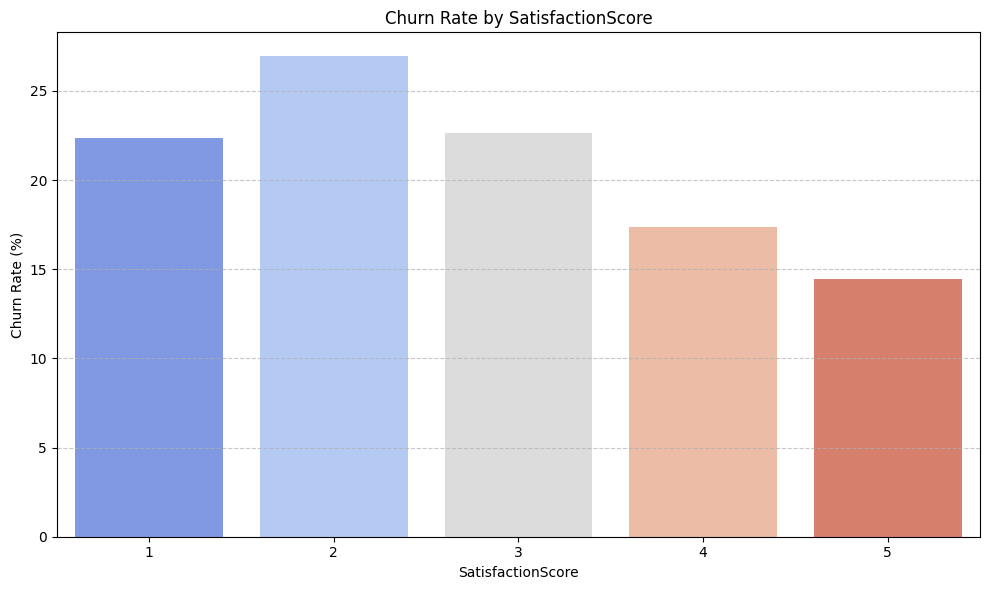

In [ ]:
# Calculate the correlation between SatisfactionScore and Exited
correlation_satisfaction_churn = df['SatisfactionScore'].corr(df['Exited'])

print(f"Correlation between SatisfactionScore and Exited: {correlation_satisfaction_churn:.3f}")

# Visualize churn rate by SatisfactionScore
churn_by_satisfaction = df.groupby('SatisfactionScore')['Exited'].mean() * 100

print("\nChurn Rate by SatisfactionScore:")
print(churn_by_satisfaction.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette='coolwarm')
plt.title('Churn Rate by SatisfactionScore')
plt.xlabel('SatisfactionScore')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the percentage of customers with Balance = 0 by cleaned Geography
zero_balance_by_geography = df.groupby('Geography')['Balance_Imputed'].apply(lambda x: (x == 0).mean() * 100)

print("Percentage of Customers with Zero Balance by Geography:")
print(zero_balance_by_geography.apply(lambda x: f'{x:.2f}%'))

# Also check the number of unique balances to confirm the statement
print("\nNumber of unique Balance values in Germany:", df[df['Geography'] == 'Germany']['Balance_Imputed'].nunique())
print("Number of customers with zero balance in Germany:", (df[df['Geography'] == 'Germany']['Balance_Imputed'] == 0).sum())

Percentage of Customers with Zero Balance by Geography:
Geography
France     43.33%
Germany     0.00%
Spain      43.38%
Name: Balance_Imputed, dtype: object

Number of unique Balance values in Germany: 2137
Number of customers with zero balance in Germany: 0


In [ ]:
# Execute the cell for calculating percentage of customers with Balance = 0 by cleaned Geography
# This cell was previously defined, re-executing it to get results for Q2.2.

### Cleaning the 'Geography' Column for Better Analysis

Cleaned Churn Rate by Geography:
Geography
France      16.11%
Germany     32.42%
Germany     32.91%
Spain       16.75%
Spain       16.22%
Name: Exited, dtype: object


/tmp/ipykernel_6258/455600076.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_geography_cleaned.index, y=churn_by_geography_cleaned.values, palette='viridis')


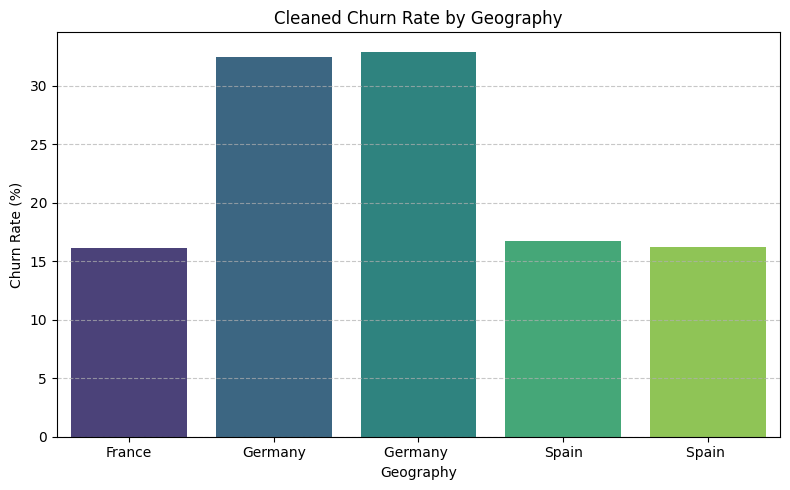

In [ ]:
# Standardize 'Geography' column
df['Geography'] = df['Geography'].replace({
    ' France': 'France', 'FR': 'France', 'france': 'France',
    ' Germany': 'Germany', 'GERMANY': 'Germany', 'germany': 'Germany',
    ' Spain': 'Spain', 'ESP': 'Spain', 'spain': 'Spain'
})

# Recalculate churn rate by cleaned Geography
churn_by_geography_cleaned = df.groupby('Geography')['Exited'].mean() * 100

print("Cleaned Churn Rate by Geography:")
print(churn_by_geography_cleaned.apply(lambda x: f'{x:.2f}%'))

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_geography_cleaned.index, y=churn_by_geography_cleaned.values, palette='viridis')
plt.title('Cleaned Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Re-examine average Balance by cleaned Geography
# Use 'Balance_Imputed' as it was created in a previous step
avg_balance_by_geography_cleaned = df.groupby('Geography')['Balance_Imputed'].mean()

print("\nCleaned Average Balance by Geography:")
print(avg_balance_by_geography_cleaned.apply(lambda x: f'{x:,.2f}'))

# Re-examine Gender distribution by cleaned Geography
gender_distribution_by_geography_cleaned = df.groupby('Geography')['Gender'].value_counts(normalize=True).unstack() * 100

print("\nCleaned Gender Distribution by Geography (%):")
print(gender_distribution_by_geography_cleaned.applymap(lambda x: f'{x:.2f}%'))


Cleaned Average Balance by Geography:
Geography
France       64,487.48
Germany     116,216.01
Germany     122,283.73
Spain        65,051.52
Spain        60,277.95
Name: Balance_Imputed, dtype: object

Cleaned Gender Distribution by Geography (%):
Gender     Female    Male
Geography                
France     45.14%  54.86%
Germany    47.57%  52.43%
Germany    45.57%  54.43%
Spain      44.14%  55.86%
Spain      41.89%  58.11%


/tmp/ipykernel_6258/166922100.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(gender_distribution_by_geography_cleaned.applymap(lambda x: f'{x:.2f}%'))
